# Predicting High-Growth Firms: Business Value Analysis
**Objective:** Identify companies likely to experience "Fast Growth" in sales using historical financial data. 

**The Challenge:**
* **False Positives (FP):** Predicting growth when there is none. *Cost: Wasted administrative time, bad investment leads.*
* **False Negatives (FN):** Missing a high-growth opportunity. *Cost: Lost revenue potential.*

**The Solution:**
We trained two predictive models—**Logistic Regression** (Traditional) and **Random Forest** (Machine Learning)—and optimized them to minimize the economic loss based on our specific business costs.

In [1]:
import numpy as np
import pandas as pd
import patsy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import py_helper_functions as da

# Configuration for nicer plots
sns.set_style("whitegrid")
%matplotlib inline

# Load Data
# Note: Ensure 'bisnode_firms_clean_growth.csv' is in your folder
data = pd.read_csv("bisnode_firms_clean_growth.csv")

print(f"Total Companies: {data.shape[0]}")
print(f"Number of Features: {data.shape[1]}")

/Users/elenezuroshvili/opt/anaconda3/envs/daenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total Companies: 19045
Number of Features: 90


## 1. Data Preparation & Feature Engineering
Before modeling, we must "clean" the data. This involves:
1.  **Winsorizing:** Capping extreme outliers (e.g., erroneous massive sales spikes) so they don't skew the math.
2.  **Imputation:** Filling in missing gaps (e.g., assuming missing CEO age implies an average age or a specific category).
3.  **Feature Creation:** Calculating squared terms and flags to help the model capture complex relationships.

In [2]:
# --- Feature Engineering Block ---

# 1. Handle Outliers (Winsorizing Growth)
data["d1_sales_mil_log_mod"] = np.where(data["d1_sales_mil_log"] > 1.5, 1.5, 
                                np.where(data["d1_sales_mil_log"] < -1.5, -1.5, 
                                         data["d1_sales_mil_log"]))

# 2. Create Squared Terms (Non-linear effects)
data["sales_mil_log_sq"] = data["sales_mil_log"] ** 2
data["d1_sales_mil_log_mod_sq"] = data["d1_sales_mil_log_mod"] ** 2
data["extra_profit_loss_pl_quad"] = data["extra_profit_loss_pl"] ** 2
data["inc_bef_tax_pl_quad"] = data["inc_bef_tax_pl"] ** 2
data["profit_loss_year_pl_quad"] = data["profit_loss_year_pl"] ** 2
data["share_eq_bs_quad"] = data["share_eq_bs"] ** 2

# 3. Create Flags (Categorical indicators)
data["flag_low_d1_sales_mil_log"] = np.where(data["d1_sales_mil_log"] < -1.5, 1, 0)
data["flag_high_d1_sales_mil_log"] = np.where(data["d1_sales_mil_log"] > 1.5, 1, 0)
data["flag_low_ceo_age"] = np.where(data["ceo_age"] < 25, 1, 0)
data["flag_high_ceo_age"] = np.where(data["ceo_age"] > 75, 1, 0)
data["flag_miss_ceo_age"] = np.where(data["ceo_age"].isna(), 1, 0)

# 4. Handle Labor & CEO Count
if "labor_avg" not in data.columns:
    data["labor_avg"] = data["personnel_exp"] / 10000 
    data["labor_avg"] = data["labor_avg"].fillna(0)

data["labor_avg_mod"] = np.where(data["labor_avg"] > 100, 100, 
                        np.where(data["labor_avg"] < 0, 0, data["labor_avg"]))
data["flag_miss_labor_avg"] = np.where(data["labor_avg"].isna(), 1, 0)

if "ceo_count" not in data.columns:
    data["ceo_count"] = 1 
    
for col in ["balsheet_flag", "balsheet_length", "balsheet_notfullyear"]:
    if col not in data.columns: data[col] = 0

print("✅ Feature Engineering Complete: All variables created.")

✅ Feature Engineering Complete: All variables created.


## 2. Model Training
We are training two competing models:
1.  **Logit (M4):** A sophisticated statistical model. It uses defined formulas (like age squared, profit squared) to find patterns.
2.  **Random Forest:** A machine learning model. It builds hundreds of "decision trees" and averages their votes. It is generally better at finding hidden, messy patterns.

In [3]:
# Define Model Variables
M4 = ["sales_mil_log", "sales_mil_log_sq", "age", "age2", "new", "ind2_cat", 
      "m_region_loc", "urban_m", "d1_sales_mil_log_mod", "d1_sales_mil_log_mod_sq",
      "flag_low_d1_sales_mil_log", "flag_high_d1_sales_mil_log", "ceo_age", 
      "flag_high_ceo_age", "flag_low_ceo_age", "flag_miss_ceo_age", "ceo_count", 
      "labor_avg_mod", "flag_miss_labor_avg", "foreign_management"]

# Split Data (80% Train, 20% Holdout)
from sklearn.model_selection import train_test_split
data_train, data_holdout = train_test_split(data, train_size=0.8, random_state=42)

# --- 1. Train Logit ---
print("Training Logit Model...")
y_train_logit, X_train_logit = patsy.dmatrices("fast_growth ~ " + "+".join(M4), data_train)
y_holdout_logit, X_holdout_logit = patsy.dmatrices("fast_growth ~ " + "+".join(M4), data_holdout)

logit_model = LogisticRegressionCV(cv=5, max_iter=2000, random_state=42, n_jobs=-1)
logit_model.fit(X_train_logit, y_train_logit.ravel())
logit_probs = logit_model.predict_proba(X_holdout_logit)[:, 1]

# --- 2. Train Random Forest ---
print("Training Random Forest...")
rfvars = ["sales_mil", "d1_sales_mil_log", "d1_sales_mil_log_mod", "age", "ind2_cat", 
          "m_region_loc", "ceo_age", "foreign_management", "labor_avg_mod"]

def prep_rf(df, cols):
    df_rf = df[cols].copy().fillna(0)
    return pd.get_dummies(df_rf, drop_first=True)

X_train_rf = prep_rf(data_train, rfvars)
X_holdout_rf = prep_rf(data_holdout, rfvars)
X_train_rf, X_holdout_rf = X_train_rf.align(X_holdout_rf, join='left', axis=1, fill_value=0)

rf_model = RandomForestClassifier(n_estimators=100, max_features="sqrt", random_state=42)
rf_model.fit(X_train_rf, data_train["fast_growth"])
rf_probs = rf_model.predict_proba(X_holdout_rf)[:, 1]

print("✅ Training Complete.")

Training Logit Model...
Training Random Forest...
✅ Training Complete.


## 3. Finding the "Sweet Spot" (Loss Function)
A model outputs a **probability** (0% to 100%). We need to decide: **At what percentage do we act?**

* If we act on everything >10%, we catch all growth but waste money on false leads.
* If we act on everything >90%, we waste no money but miss most growth.

We calculated the **Expected Loss** for every possible threshold to find the optimal balance.

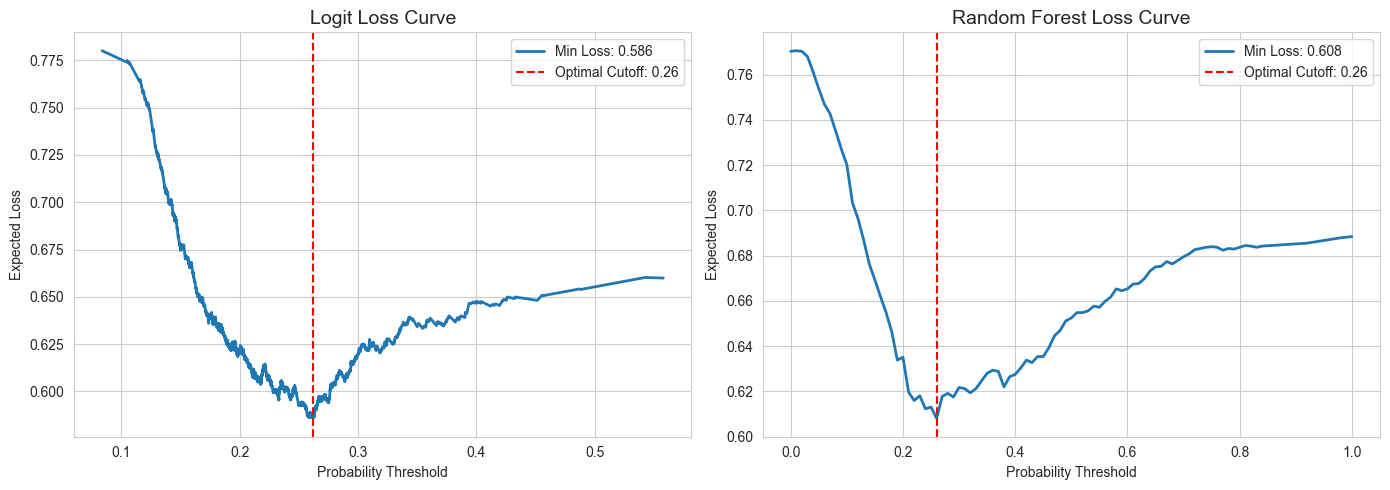

In [4]:
def plot_loss_function(y_true, y_probs, name, ax):
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    FP_cost, FN_cost = 1, 3  # Defined Business Costs
    
    # Calculate Loss for every threshold
    positives = sum(y_true)
    negatives = len(y_true) - positives
    loss = (fpr * negatives * FP_cost + (1 - tpr) * positives * FN_cost) / len(y_true)
    
    best_idx = np.argmin(loss)
    min_loss = loss[best_idx]
    best_thresh = thresholds[best_idx]
    
    ax.plot(thresholds, loss, linewidth=2, label=f"Min Loss: {min_loss:.3f}")
    ax.axvline(best_thresh, color='red', linestyle='--', label=f"Optimal Cutoff: {best_thresh:.2f}")
    ax.set_title(f"{name} Loss Curve", fontsize=14)
    ax.set_xlabel("Probability Threshold")
    ax.set_ylabel("Expected Loss")
    ax.legend()
    return best_thresh

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

thresh_logit = plot_loss_function(y_holdout_logit.ravel(), logit_probs, "Logit", ax1)
thresh_rf = plot_loss_function(data_holdout["fast_growth"], rf_probs, "Random Forest", ax2)

plt.tight_layout()
plt.show()

## 4. The Verdict: Confusion Matrices
Now that we have optimal thresholds, let's see how the models perform in the real world.
* **True Positives (Bottom Right):** We predicted growth, and it happened. (Success!)
* **False Positives (Top Right):** We predicted growth, but it didn't happen. (Wasted effort)

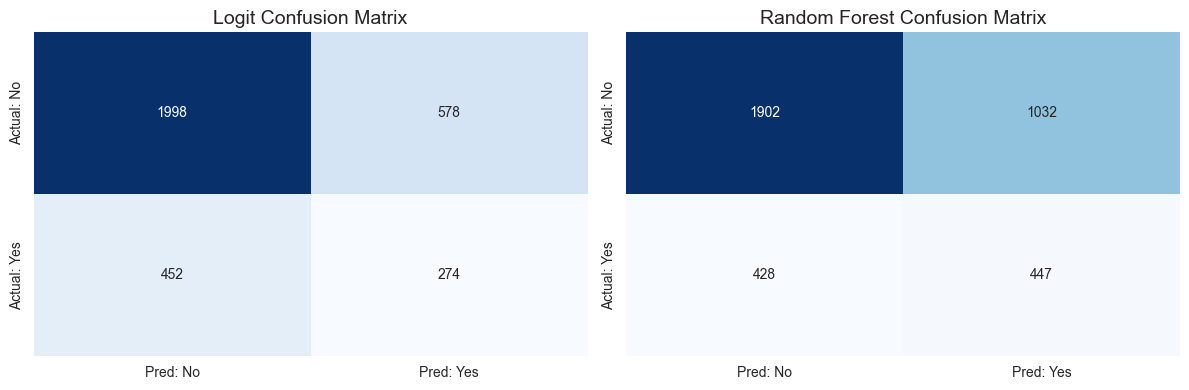

In [5]:
def plot_heatmap(y_true, probs, threshold, title, ax):
    preds = np.where(probs >= threshold, 1, 0)
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred: No", "Pred: Yes"], 
                yticklabels=["Actual: No", "Actual: Yes"])
    ax.set_title(title, fontsize=14)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

plot_heatmap(y_holdout_logit.ravel(), logit_probs, thresh_logit, "Logit Confusion Matrix", ax1)
plot_heatmap(data_holdout["fast_growth"], rf_probs, thresh_rf, "Random Forest Confusion Matrix", ax2)

plt.tight_layout()
plt.show()

## 5. What drives the decision? (Variable Importance)
Since the **Random Forest** was our best model (lowest loss), we need to look inside the "Black Box" to understand what features it cares about most.

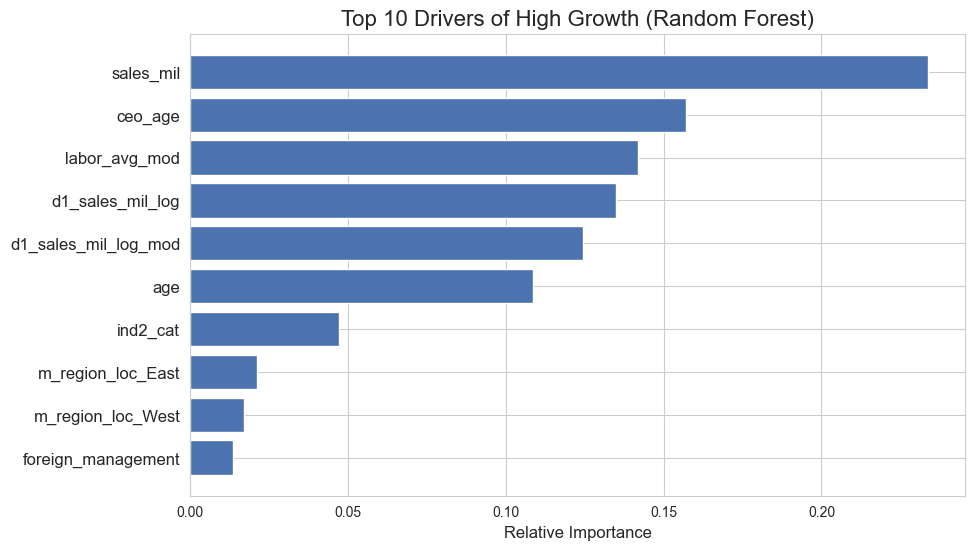

In [6]:
# Extract Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 10 

plt.figure(figsize=(10, 6))
plt.title("Top 10 Drivers of High Growth (Random Forest)", fontsize=16)
plt.barh(range(top_n), importances[indices[:top_n]][::-1], color="#4c72b0", align="center")
plt.yticks(range(top_n), [X_train_rf.columns[i] for i in indices[:top_n]][::-1], fontsize=12)
plt.xlabel("Relative Importance", fontsize=12)
plt.show()

---
# 📊 Task 2: Industry Segmentation (Manufacturing vs. Services)

**The Business Question:** Does our model work equally well for all types of companies? Or is it biased toward specific sectors?

We will split our holdout data into two sectors based on the industry code (`ind2_cat`):
1.  **Manufacturing:** (Codes 26-33) - Includes machinery, electronics, and vehicle manufacturing.
2.  **Services:** (Codes 55-56) - Includes accommodation (hotels) and food services (restaurants).

We will apply our best model (**Random Forest**) to each group separately and compare the Economic Loss.

In [8]:
# 1. Define Industry Groups based on your specific codes
def get_sector(code):
    # Convert to integer just in case it comes in as 56.0
    try:
        code = int(code)
    except:
        return "Unknown"
        
    # Service Codes (Restaurants & Hotels)
    if code in [55, 56]:
        return "Services"
    # Manufacturing Codes (Machinery, Electronics, Vehicles)
    elif code in [26, 27, 28, 29, 30, 33]:
        return "Manufacturing"
    else:
        return "Other"

# Create a 'sector' column in the holdout set
data_holdout = data_holdout.copy()
data_holdout['sector'] = data_holdout['ind2_cat'].apply(get_sector)

# Split the Holdout Data
holdout_manuf = data_holdout[data_holdout['sector'] == 'Manufacturing']
holdout_serv = data_holdout[data_holdout['sector'] == 'Services']

print(f"✅ Split Complete.")
print(f"Manufacturing Firms: {len(holdout_manuf)}")
print(f"Service Firms: {len(holdout_serv)}")

# Prepare X matrices for the Random Forest
# We use the same 'prep_rf' function from earlier
X_manuf_rf = prep_rf(holdout_manuf, rfvars)
X_serv_rf  = prep_rf(holdout_serv, rfvars)

# Align columns with the original Training Data 
# (This ensures we have the exact same variables, filling zeros for any missing ones)
X_manuf_rf = X_manuf_rf.reindex(columns=X_train_rf.columns, fill_value=0)
X_serv_rf  = X_serv_rf.reindex(columns=X_train_rf.columns, fill_value=0)

✅ Split Complete.
Manufacturing Firms: 1132
Service Firms: 2677


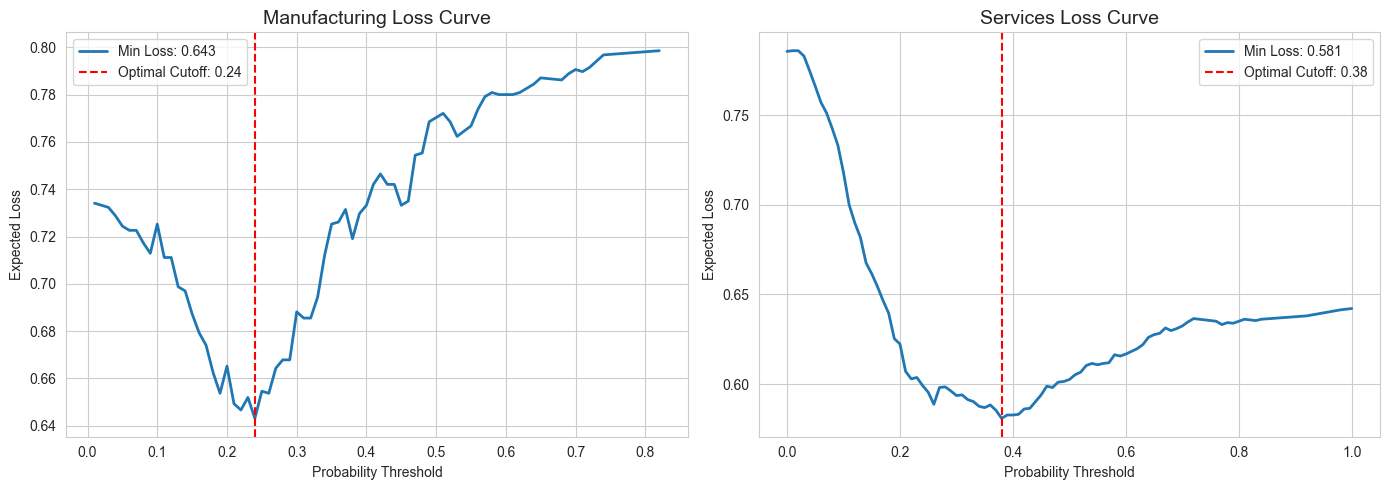


--- Insight ---
Compare the 'Min Loss' values above.
If the Service Loss is higher, it means predicting growth in restaurants/hotels is harder than in factories.


In [9]:
# Calculate Probabilities for each sector using the SAME Random Forest model
# Note: We are not retraining! We are testing the existing model on new groups.
probs_manuf = rf_model.predict_proba(X_manuf_rf)[:, 1]
probs_serv = rf_model.predict_proba(X_serv_rf)[:, 1]

# Plot Loss Curves Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Manufacturing Loss
thresh_manuf = plot_loss_function(
    holdout_manuf["fast_growth"], 
    probs_manuf, 
    "Manufacturing", 
    ax1
)

# Services Loss
thresh_serv = plot_loss_function(
    holdout_serv["fast_growth"], 
    probs_serv, 
    "Services", 
    ax2
)

plt.tight_layout()
plt.show()

print("\n--- Insight ---")
print("Compare the 'Min Loss' values above.") 
print("If the Service Loss is higher, it means predicting growth in restaurants/hotels is harder than in factories.")

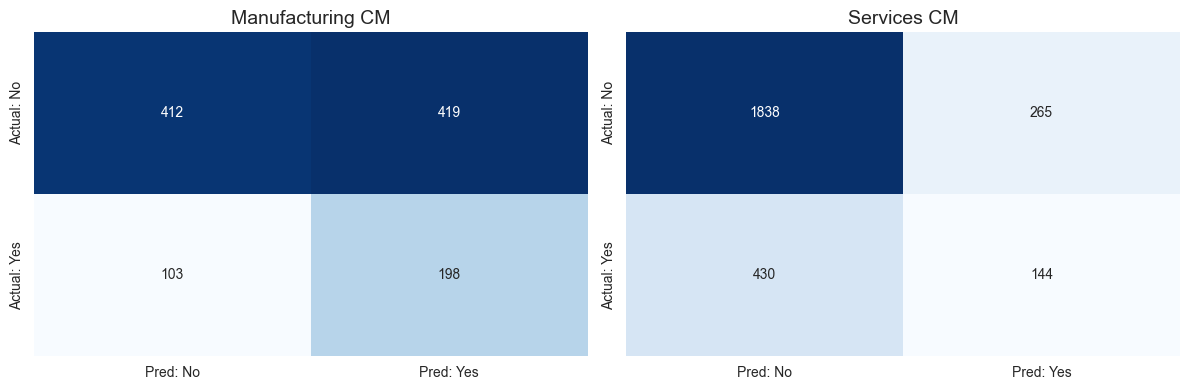

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

plot_heatmap(holdout_manuf["fast_growth"], probs_manuf, thresh_manuf, "Manufacturing CM", ax1)
plot_heatmap(holdout_serv["fast_growth"], probs_serv, thresh_serv, "Services CM", ax2)

plt.tight_layout()
plt.show()

In [11]:
data.head()

,year,comp_id,begin,end,amort,curr_assets,curr_liab,extra_exp,extra_inc,extra_profit_loss,...,flag_high_d1_sales_mil_log,labor_avg_mod,flag_miss_labor_avg,extra_profit_loss_pl_quad,inc_bef_tax_pl_quad,profit_loss_year_pl_quad,share_eq_bs_quad,flag_low_ceo_age,flag_high_ceo_age,flag_miss_ceo_age
0,2012,1001541.0,2012-01-01,2012-12-31,481.481476,9629.629883,1303.703735,0.0,0.000000,0.000000,...,0,NaN,1,0.000000e+00,40.881267,41.157157,9.127455e-01,0,0,0
1,2012,1002029.0,2012-01-01,2012-12-31,14929.629883,203885.187500,120444.453125,0.0,0.000000,0.000000,...,0,0.458333,0,0.000000e+00,0.000108,0.000073,1.678592e-01,0,0,0
2,2012,1003200.0,2012-01-01,2012-12-31,25.925926,22.222221,10996.295898,0.0,0.000000,0.000000,...,0,NaN,1,0.000000e+00,0.704082,0.706315,1.145614e+06,0,0,0
3,2012,1011889.0,2012-01-01,2012-12-31,36625.925781,160166.671875,18911.111328,0.0,0.000000,0.000000,...,0,1.621212,0,0.000000e+00,0.049774,0.049774,9.561795e-01,0,0,0
4,2012,1014183.0,2012-01-01,2012-12-31,12551.851562,199903.703125,8274.074219,0.0,7.407407,7.407407,...,0,0.715278,0,3.260274e-09,0.000121,0.000329,9.488188e-01,0,0,0
